# Logistic Regression: Predicting Frustration from Heart Rate (HR)

In this notebook we build a logistic regression model that predicts whether a person is **frustrated** or **not frustrated** based on heart-rate measurements (HR features) from `HR_data.csv`.

`Frustrated` is given on a scale from 0-10 (here 0-8), so we convert it into a binary variable (0 = not frustrated, 1 = frustrated) using a threshold value, which you can adjust yourself.

**Important note on the dataset structure:** The dataset contains repeated measurements from 14 individuals (12 measurements per person, corresponding to 4 rounds x 3 phases). If we make a completely random train/test split, measurements from the same person could end up in both the training and test sets (*data leakage*). The model would then partly learn to recognize the individual person instead of a general pattern between heart rate and frustration. For the model's predictions to be usable on new, unseen people ("a future random dataset"), we use:

1. **Nested Leave-One-Subject-Out (LOSO) cross-validation**: with only 14 individuals, a single random hold-out test set would only contain 2-4 people — far too noisy an estimate. Instead, the **outer loop** leaves out one individual at a time (`LeaveOneGroupOut`, 14 folds), giving 14 independent test sets that together cover the whole dataset.
2. **Inner cross-validation** (`StratifiedGroupKFold` on the remaining 13 individuals) together with `GridSearchCV` selects hyperparameters (regularization strength `C` and `class_weight`) and the decision threshold, *without ever using the outer fold's held-out individual*.
3. A `Pipeline` that combines a `ColumnTransformer` (standardizing the HR features and one-hot
   encoding `Phase`/`Round`) with the model, so all preprocessing is only fitted on the training
   fold in each cross-validation split (avoids leakage).
4. After the nested LOSO evaluation (which gives our honest performance estimate), we fit one **final model on all 14 individuals** (using the same CV procedure) purely to *interpret* the model (coefficients, decision boundary) — this final model is not used for performance claims.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    LeaveOneGroupOut,
    StratifiedGroupKFold,
    GridSearchCV,
    cross_val_predict,
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
)

## 1. Load data

In [2]:
df = pd.read_csv("HR_data.csv", index_col=0)
df.head()

,HR_Mean,HR_Median,HR_std,HR_Min,HR_Max,HR_AUC,Round,Phase,Individual,Puzzler,Frustrated,Cohort
0,77.965186,78.00,3.345290,73.23,83.37,22924.945,round_3,phase3,1,1,1,D1_1
1,70.981097,70.57,2.517879,67.12,78.22,21930.400,round_3,phase2,1,1,5,D1_1
2,73.371959,73.36,3.259569,67.88,80.22,21647.085,round_3,phase1,1,1,0,D1_1
3,78.916822,77.88,4.054595,72.32,84.92,25258.905,round_2,phase3,1,1,1,D1_1
4,77.322226,74.55,6.047603,70.52,90.15,23890.565,round_2,phase2,1,1,5,D1_1


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 168 entries, 0 to 167
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   HR_Mean     168 non-null    float64
 1   HR_Median   168 non-null    float64
 2   HR_std      168 non-null    float64
 3   HR_Min      168 non-null    float64
 4   HR_Max      168 non-null    float64
 5   HR_AUC      168 non-null    float64
 6   Round       168 non-null    object 
 7   Phase       168 non-null    object 
 8   Individual  168 non-null    int64  
 9   Puzzler     168 non-null    int64  
 10  Frustrated  168 non-null    int64  
 11  Cohort      168 non-null    object 
dtypes: float64(6), int64(3), object(3)
memory usage: 17.1+ KB


,HR_Mean,HR_Median,HR_std,HR_Min,HR_Max,HR_AUC,Individual,Puzzler,Frustrated
count,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.00000,168.000000,168.000000
mean,76.009226,74.821458,6.041234,67.422679,89.062024,23398.551815,7.50000,0.500000,2.291667
std,7.501301,8.101459,4.267282,7.042010,12.764559,3589.600223,4.04318,0.501495,1.924796
min,57.341463,54.130000,0.844255,52.180000,70.150000,15975.450000,1.00000,0.000000,0.000000
25%,70.952240,70.175000,3.092851,62.645000,79.752500,20805.553750,4.00000,0.000000,1.000000
50%,75.618503,74.625000,4.678773,67.540000,87.355000,22493.687500,7.50000,0.500000,2.000000
75%,80.308459,79.010000,7.281001,71.922500,94.682500,25645.200000,11.00000,1.000000,4.000000
max,96.159341,94.880000,21.880307,82.680000,137.670000,35299.460000,14.00000,1.000000,8.000000


## 2. Convert frustration into a binary variable

`Frustrated` ranges from 0 to 8 in the dataset. We choose a threshold (`threshold`), so that all values >= threshold become class 1 ("frustrated"), and all values below become class 0 ("not frustrated").

You can change `threshold` to see how the class balance and the model's performance change.


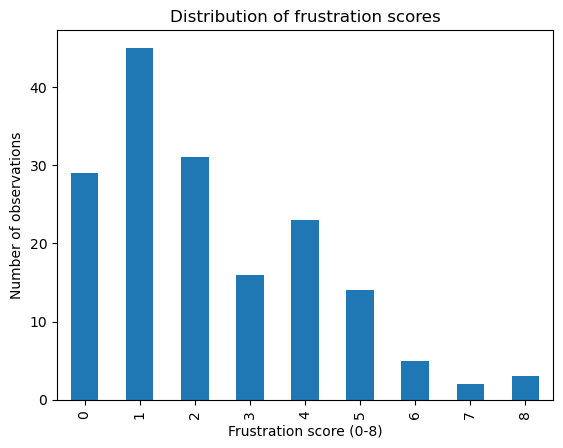

In [4]:
# Distribution of the raw frustration scores
df["Frustrated"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Frustration score (0-8)")
plt.ylabel("Number of observations")
plt.title("Distribution of frustration scores")
plt.show()


In [5]:
threshold = 3  # adjust as needed (>= threshold => frustrated = 1)

df["Frustrated_binary"] = (df["Frustrated"] >= threshold).astype(int)

print(df["Frustrated_binary"].value_counts())
print(f"\nProportion frustrated (class 1): {df['Frustrated_binary'].mean():.2%}")


Frustrated_binary
0    105
1     63
Name: count, dtype: int64

Proportion frustrated (class 1): 37.50%


## 3. Per-individual normalization of HR features

Resting heart rate and heart-rate variability differ a lot from person to person (e.g. due to fitness level, age, caffeine). This **between-individual variation** can dominate the raw HR features and mask the **within-individual variation** that actually relates to frustration (i.e. whether a person's own heart rate is higher/lower than their own normal level).

We therefore z-score-normalize each HR feature **per individual**: for each person we subtract that person's own mean and divide by that person's own standard deviation (computed across the person's 12 measurements). The result is how many standard deviations a given measurement deviates from that person's *own* normal level.

*Note:* This corresponds to assuming access to a short calibration/baseline period for new individuals (which matches the experiment's design with a rest phase in each round) — it therefore still makes sense for "future, unseen individuals", as long as they also have a baseline measurement.


In [6]:
raw_feature_cols = ["HR_Mean", "HR_Median", "HR_std", "HR_Max", "HR_AUC"]

df_norm = df.copy()
for col in raw_feature_cols:
    df_norm[col] = df.groupby("Individual")[col].transform(lambda s: (s - s.mean()) / s.std())

df_norm[raw_feature_cols].describe()

,HR_Mean,HR_Median,HR_std,HR_Max,HR_AUC
count,1.680000e+02,1.680000e+02,1.680000e+02,1.680000e+02,1.680000e+02
mean,6.079793e-17,-1.059999e-15,-3.700743e-17,-5.709718e-16,-6.079793e-17
std,9.602894e-01,9.602894e-01,9.602894e-01,9.602894e-01,9.602894e-01
min,-2.090416e+00,-2.320427e+00,-1.561129e+00,-1.751144e+00,-1.571144e+00
25%,-7.280204e-01,-7.704507e-01,-6.933782e-01,-7.559462e-01,-6.944055e-01
50%,-2.775503e-02,-8.617163e-02,-3.165731e-01,-2.086793e-01,-2.577854e-01
75%,6.248084e-01,6.679727e-01,5.324870e-01,5.103417e-01,5.597943e-01
max,2.091565e+00,2.416027e+00,2.897812e+00,2.546851e+00,2.937623e+00


## 4. Choose features (heart rate), target and groups

**Feature set:** `HR_data.csv` has 6 HR features (`HR_Mean`, `HR_Median`, `HR_std`, `HR_Min`,
`HR_Max`, `HR_AUC`). Based on the correlation analysis in `feature_correlation_analysis.ipynb`, we
use 5 of these — `HR_Mean`, `HR_Median`, `HR_std`, `HR_Max`, `HR_AUC` — and drop `HR_Min`. In
addition, we one-hot encode `Phase` (3 levels) and `Round` (4 levels) and include them as features,
so the model can also learn from which phase/round a measurement was taken. All three model
notebooks are trained on this same fixed feature set: the 5 HR features plus one-hot encoded
`Phase`/`Round`. No automatic feature selection is applied.

We use these 5 (per-individual normalized) HR features plus `Phase`/`Round` as predictors (X), the
binary frustration as the target (y), and `Individual` as the group variable. The group is used to
ensure that all measurements from the same person end up in either the training set or the test
set — never both.


In [7]:
feature_cols = raw_feature_cols + ["Phase", "Round"]

X = df_norm[feature_cols]
y = df_norm["Frustrated_binary"]
groups = df_norm["Individual"]

X.head()

,HR_Mean,HR_Median,HR_std,HR_Max,HR_AUC,Phase,Round
0,1.097189,1.223550,-0.030634,0.495003,-0.255968,phase3,round_3
1,-1.593119,-1.723680,-0.714876,-0.999437,-0.547102,phase2,round_3
2,-0.672146,-0.616981,-0.101523,-0.419072,-0.630037,phase1,round_3
3,1.463764,1.175950,0.555938,0.944786,0.427252,phase3,round_2
4,0.849517,-0.144948,2.204090,2.462439,0.026698,phase2,round_2


### Features used in this model

This logistic regression is trained on **10 preprocessed columns** derived from the 7 columns of
`X` shown above — no automatic feature selection is applied, every fold's model uses all of them:

- `HR_Mean`, `HR_Median`, `HR_std`, `HR_Max`, `HR_AUC` (each z-scored per individual, Section 3,
  then standardized again inside the pipeline's `ColumnTransformer`).
- `Phase` — one-hot encoded into `Phase_phase2`, `Phase_phase3` (`phase1` is the dropped/reference
  level).
- `Round` — one-hot encoded into `Round_round_2`, `Round_round_3`, `Round_round_4` (`round_1` is
  the dropped/reference level).

`HR_Min` and `Individual`/`groups` are **not** used as predictors. `Individual` is only used to
define the LOSO train/test splits so that no individual appears in both the training and test set
of a fold.

## 5. Nested Leave-One-Subject-Out (LOSO) cross-validation

With only 14 individuals, we use **nested LOSO**:

- **Outer loop** (`LeaveOneGroupOut`, grouped by `Individual`): one individual at a time is held out as the test set (12 rows). The model never sees this person's data during training or hyperparameter tuning for this fold.
- **Inner loop** (`StratifiedGroupKFold` on the remaining 13 individuals): used by `GridSearchCV` to select `C` and `class_weight`, and to generate out-of-fold probabilities for choosing the decision threshold (Youden's J statistic), exactly as before — but now entirely *within* the outer training set.
- The tuned pipeline is refit on all 13 training individuals and evaluated **once** on the held-out individual.

This is repeated 14 times (once per individual), so every observation in the dataset gets exactly one out-of-fold prediction. The metrics computed from these 168 out-of-fold predictions are our honest estimate of how the model generalizes to a new person.


In [8]:
preprocessor = ColumnTransformer([
    ("hr", StandardScaler(), raw_feature_cols),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), ["Phase", "Round"]),
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])

param_grid = {
    "clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "clf__class_weight": [None, "balanced"],
}

outer_cv = LeaveOneGroupOut()

oof_true = np.zeros(len(y), dtype=int)
oof_pred = np.zeros(len(y), dtype=int)
oof_proba = np.zeros(len(y), dtype=float)
fold_records = []

for fold_i, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups=groups)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    groups_tr = groups.iloc[train_idx]
    test_individual = groups.iloc[test_idx].iloc[0]

    # Inner CV (13 training individuals): hyperparameter tuning
    inner_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    grid_search = GridSearchCV(
        pipeline, param_grid, cv=inner_cv, scoring="balanced_accuracy", n_jobs=-1,
    )
    grid_search.fit(X_tr, y_tr, groups=groups_tr)
    best_model = grid_search.best_estimator_

    # Inner CV out-of-fold probabilities: threshold selection (Youden's J)
    inner_oof_proba = cross_val_predict(
        best_model, X_tr, y_tr, groups=groups_tr, cv=inner_cv, method="predict_proba"
    )[:, 1]
    fpr_in, tpr_in, thr_in = roc_curve(y_tr, inner_oof_proba)
    threshold = thr_in[np.argmax(tpr_in - fpr_in)]

    # Evaluate once on the held-out individual
    proba_te = best_model.predict_proba(X_te)[:, 1]
    pred_te = (proba_te >= threshold).astype(int)

    oof_true[test_idx] = y_te.values
    oof_proba[test_idx] = proba_te
    oof_pred[test_idx] = pred_te

    fold_records.append({
        "Individual": int(test_individual),
        "best_C": grid_search.best_params_["clf__C"],
        "best_class_weight": grid_search.best_params_["clf__class_weight"],
        "threshold": threshold,
        "accuracy": accuracy_score(y_te, pred_te),
        "balanced_accuracy": balanced_accuracy_score(y_te, pred_te),
    })

    print(f"Fold {fold_i + 1:2d}/14 (Individual {int(test_individual):2d}): "
          f"C={grid_search.best_params_['clf__C']!s:>6}, "
          f"class_weight={str(grid_search.best_params_['clf__class_weight']):>8}, "
          f"threshold={threshold:.3f}, "
          f"accuracy={accuracy_score(y_te, pred_te):.3f}")

fold_df = pd.DataFrame(fold_records)
fold_df

Fold  1/14 (Individual  1): C=     1, class_weight=    None, threshold=0.455, accuracy=1.000
Fold  2/14 (Individual  2): C=     1, class_weight=    None, threshold=0.467, accuracy=0.917


Fold  3/14 (Individual  3): C=   0.1, class_weight=balanced, threshold=0.564, accuracy=0.167
Fold  4/14 (Individual  4): C=     1, class_weight=balanced, threshold=0.526, accuracy=0.750


Fold  5/14 (Individual  5): C=     1, class_weight=balanced, threshold=0.602, accuracy=0.750
Fold  6/14 (Individual  6): C=     1, class_weight=balanced, threshold=0.564, accuracy=0.583


Fold  7/14 (Individual  7): C=     1, class_weight=balanced, threshold=0.557, accuracy=0.583
Fold  8/14 (Individual  8): C=     1, class_weight=    None, threshold=0.436, accuracy=1.000


Fold  9/14 (Individual  9): C=     1, class_weight=    None, threshold=0.481, accuracy=0.833
Fold 10/14 (Individual 10): C=     1, class_weight=    None, threshold=0.525, accuracy=0.833


Fold 11/14 (Individual 11): C=   0.1, class_weight=balanced, threshold=0.548, accuracy=0.917
Fold 12/14 (Individual 12): C=   0.1, class_weight=balanced, threshold=0.560, accuracy=0.917


Fold 13/14 (Individual 13): C=     1, class_weight=    None, threshold=0.476, accuracy=0.583
Fold 14/14 (Individual 14): C=   0.1, class_weight=balanced, threshold=0.523, accuracy=0.917


,Individual,best_C,best_class_weight,threshold,accuracy,balanced_accuracy
0,1,1.0,None,0.455116,1.000000,1.000000
1,2,1.0,None,0.467332,0.916667,0.875000
2,3,0.1,balanced,0.564258,0.166667,0.187500
3,4,1.0,balanced,0.526363,0.750000,0.728571
4,5,1.0,balanced,0.601619,0.750000,0.785714
5,6,1.0,balanced,0.563712,0.583333,0.583333
6,7,1.0,balanced,0.557480,0.583333,0.722222
7,8,1.0,None,0.436348,1.000000,1.000000
8,9,1.0,None,0.480646,0.833333,0.812500
9,10,1.0,None,0.525076,0.833333,0.909091


## 6. Aggregated nested-LOSO performance

Each of the 168 rows now has exactly one out-of-fold prediction, made by a model that never saw that individual during training or tuning. We pool all 168 predictions together to compute overall performance metrics — this is the headline result of this notebook.

Nested LOSO accuracy:          0.768
Nested LOSO balanced accuracy: 0.738
Nested LOSO ROC-AUC:           0.773

Classification report (all 168 out-of-fold predictions):
                precision    recall  f1-score   support

Not frustrated       0.79      0.86      0.82       105
    Frustrated       0.72      0.62      0.67        63

      accuracy                           0.77       168
     macro avg       0.76      0.74      0.74       168
  weighted avg       0.76      0.77      0.76       168



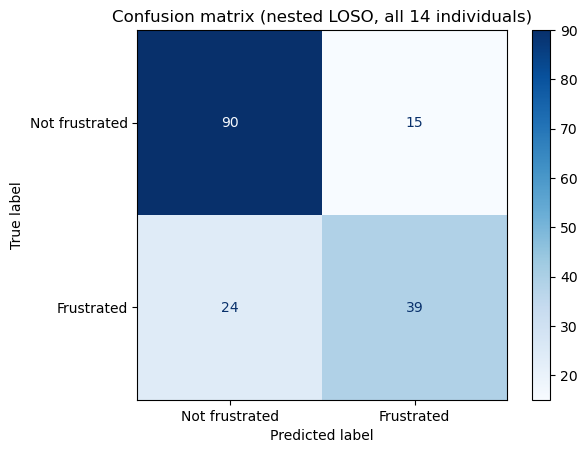

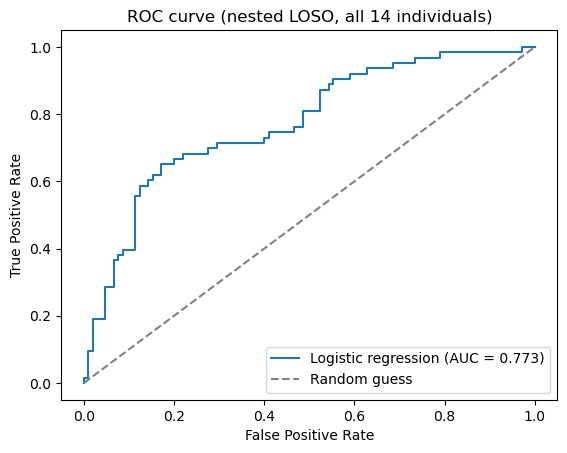

In [9]:
overall_accuracy = accuracy_score(oof_true, oof_pred)
overall_balanced_accuracy = balanced_accuracy_score(oof_true, oof_pred)
overall_auc = roc_auc_score(oof_true, oof_proba)

print(f"Nested LOSO accuracy:          {overall_accuracy:.3f}")
print(f"Nested LOSO balanced accuracy: {overall_balanced_accuracy:.3f}")
print(f"Nested LOSO ROC-AUC:           {overall_auc:.3f}\n")
print("Classification report (all 168 out-of-fold predictions):")
print(classification_report(oof_true, oof_pred, target_names=["Not frustrated", "Frustrated"], zero_division=0))

cm = confusion_matrix(oof_true, oof_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not frustrated", "Frustrated"])
disp.plot(cmap="Blues")
plt.title("Confusion matrix (nested LOSO, all 14 individuals)")
plt.show()

fpr, tpr, _ = roc_curve(oof_true, oof_proba)
plt.plot(fpr, tpr, label=f"Logistic regression (AUC = {overall_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve (nested LOSO, all 14 individuals)")
plt.legend()
plt.show()

## 7. Per-individual performance

Because each outer fold corresponds to exactly one individual, we get 14 separate accuracy/balanced-accuracy scores — one per person. This shows whether performance is consistent across individuals or driven by a few easy/hard cases, and which hyperparameters get selected most often.

 Individual  best_C best_class_weight  threshold  accuracy  balanced_accuracy
          3     0.1          balanced   0.564258  0.166667           0.187500
         13     1.0              None   0.475622  0.583333           0.318182
          6     1.0          balanced   0.563712  0.583333           0.583333
          7     1.0          balanced   0.557480  0.583333           0.722222
          4     1.0          balanced   0.526363  0.750000           0.728571
          5     1.0          balanced   0.601619  0.750000           0.785714
          9     1.0              None   0.480646  0.833333           0.812500
          2     1.0              None   0.467332  0.916667           0.875000
         14     0.1          balanced   0.523419  0.916667           0.900000
         10     1.0              None   0.525076  0.833333           0.909091
         11     0.1          balanced   0.547678  0.916667           0.944444
         12     0.1          balanced   0.559781  0.916667      

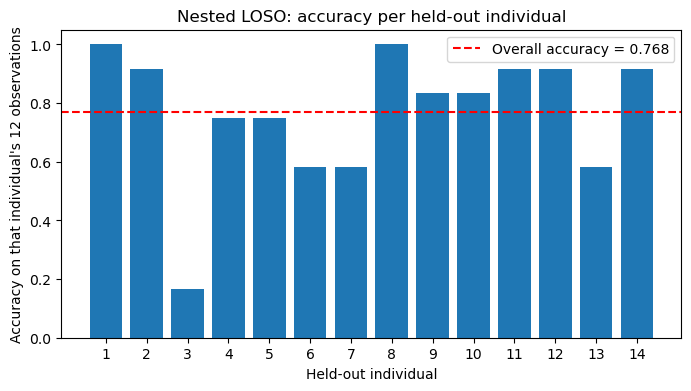

In [10]:
print(fold_df[["Individual", "best_C", "best_class_weight", "threshold", "accuracy", "balanced_accuracy"]]
      .sort_values("balanced_accuracy").to_string(index=False))

print(f"\nMean per-individual accuracy:          {fold_df['accuracy'].mean():.3f} ± {fold_df['accuracy'].std():.3f}")
print(f"Mean per-individual balanced accuracy: {fold_df['balanced_accuracy'].mean():.3f} ± {fold_df['balanced_accuracy'].std():.3f}")

plt.figure(figsize=(8, 4))
plt.bar(fold_df["Individual"].astype(str), fold_df["accuracy"])
plt.axhline(overall_accuracy, color="red", linestyle="--", label=f"Overall accuracy = {overall_accuracy:.3f}")
plt.xlabel("Held-out individual")
plt.ylabel("Accuracy on that individual's 12 observations")
plt.title("Nested LOSO: accuracy per held-out individual")
plt.legend()
plt.show()

## 8. Final model (fit on all individuals) for interpretation

The nested LOSO loop above already gives us an honest performance estimate, but it produced 14 slightly different models (one per fold). To *interpret* the model (coefficients, decision boundary), we fit **one final model on all 14 individuals**, using the exact same procedure (inner `StratifiedGroupKFold` + `GridSearchCV` + Youden's J threshold). This final model is not used for any performance claims — those come from section 6 above.

In [11]:
final_inner_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

final_grid_search = GridSearchCV(
    pipeline, param_grid, cv=final_inner_cv, scoring="balanced_accuracy", n_jobs=-1,
)
final_grid_search.fit(X, y, groups=groups)
final_model = final_grid_search.best_estimator_

final_oof_proba = cross_val_predict(
    final_model, X, y, groups=groups, cv=final_inner_cv, method="predict_proba"
)[:, 1]
fpr_f, tpr_f, thr_f = roc_curve(y, final_oof_proba)
final_threshold = thr_f[np.argmax(tpr_f - fpr_f)]

print(f"Final model hyperparameters: {final_grid_search.best_params_}")
print(f"Final model threshold (Youden's J, full-data CV): {final_threshold:.3f}")

Final model hyperparameters: {'clf__C': 1, 'clf__class_weight': 'balanced'}
Final model threshold (Youden's J, full-data CV): 0.474


## 9. Visualize the decision boundary (PCA)

The final model uses 10 preprocessed features (5 standardized HR features plus one-hot encoded
`Phase`/`Round`), so the decision boundary cannot be drawn directly. Instead:

1. We apply the fitted `ColumnTransformer` (preprocessor) to `X`, then reduce the resulting
   10 columns to 2 components with PCA — for visualization only.
2. We create a fine grid in PCA space and "project" each grid point back to the 10-dimensional
   preprocessed space (`pca.inverse_transform`).
3. We use the **final model**'s classifier to compute P(frustrated) for each grid point.

The color scale shows the model's predicted probability, and the black contour marks the final model's threshold — i.e. the decision boundary.

Explained variance: PC1 = 55.7%, PC2 = 18.1%, total = 73.9%


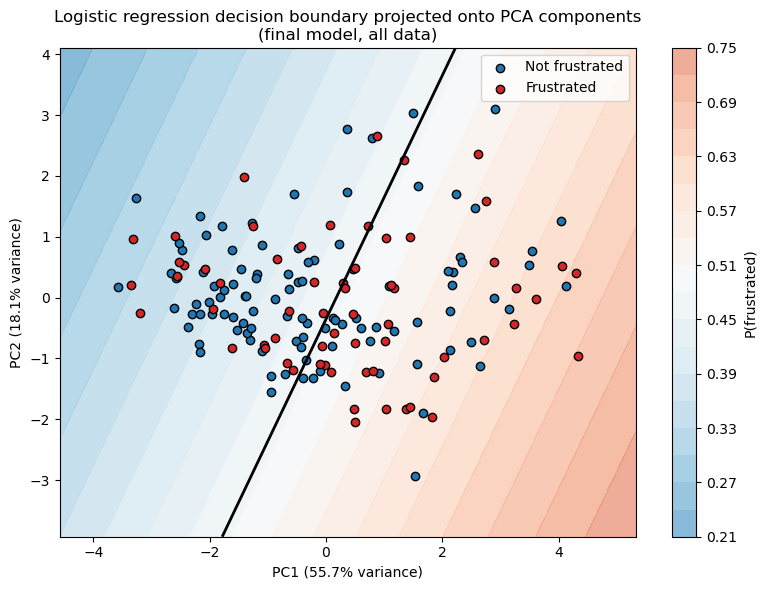

In [12]:
preprocessor_fitted = final_model.named_steps["preprocessor"]
clf = final_model.named_steps["clf"]

X_selected = preprocessor_fitted.transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_selected)

print(f"Explained variance: PC1 = {pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2 = {pca.explained_variance_ratio_[1]:.1%}, "
      f"total = {pca.explained_variance_ratio_.sum():.1%}")

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

grid_selected = pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()])
grid_proba = clf.predict_proba(grid_selected)[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(xx, yy, grid_proba, levels=20, cmap="RdBu_r", alpha=0.7, vmin=0, vmax=1)
ax.contour(xx, yy, grid_proba, levels=[final_threshold], colors="black", linewidths=2)

ax.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1],
           c="tab:blue", edgecolor="k", label="Not frustrated")
ax.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1],
           c="tab:red", edgecolor="k", label="Frustrated")

fig.colorbar(contour, ax=ax, label="P(frustrated)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("Logistic regression decision boundary projected onto PCA components\n(final model, all data)")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Interpreting the coefficients

Since the features are standardized/one-hot encoded inside the pipeline's `ColumnTransformer`, we
can directly compare the magnitude of the coefficients to see which heart-rate measures and
phase/round indicators contribute most to predicting frustration. A positive sign means that
higher values of the feature (or, for one-hot columns, being in that category) are associated with
a higher probability of frustration, and vice versa for a negative sign.

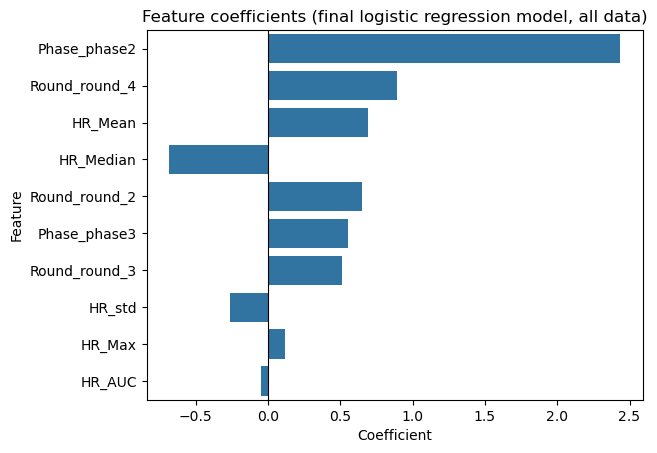

,Feature,Coefficient
5,Phase_phase2,2.434086
9,Round_round_4,0.894437
0,HR_Mean,0.693883
1,HR_Median,-0.683451
7,Round_round_2,0.649827
6,Phase_phase3,0.552587
8,Round_round_3,0.510182
2,HR_std,-0.264975
3,HR_Max,0.119578
4,HR_AUC,-0.048517


In [13]:
feature_names_out = [name.split("__", 1)[-1] for name in preprocessor_fitted.get_feature_names_out()]

coef_df = pd.DataFrame({
    "Feature": feature_names_out,
    "Coefficient": clf.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False)

sns.barplot(data=coef_df, x="Coefficient", y="Feature", orient="h")
plt.title("Feature coefficients (final logistic regression model, all data)")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()

coef_df

## 11. Save out-of-fold results for model comparison

We save the pooled nested-LOSO out-of-fold predictions (`oof_true`, `oof_pred`, `oof_proba`) and the
per-individual fold metrics, so they can be compared against the other two models in
`model_comparison.ipynb`.

In [14]:
np.savez(
    "results_logreg.npz",
    model_name="Logistic Regression",
    oof_true=oof_true,
    oof_pred=oof_pred,
    oof_proba=oof_proba,
    fold_individual=fold_df["Individual"].to_numpy(),
    fold_accuracy=fold_df["accuracy"].to_numpy(),
    fold_balanced_accuracy=fold_df["balanced_accuracy"].to_numpy(),
)
print("Saved nested-LOSO results to results_logreg.npz")

Saved nested-LOSO results to results_logreg.npz
